In [1]:
!pip install numpy matplotlib scikit-learn

     ---------------------------------------- 8.1/8.1 MB 9.4 MB/s eta 0:00:00
     -------------------------------------- 222.0/222.0 kB 6.8 MB/s eta 0:00:00
     ---------------------------------------- 72.0/72.0 kB 4.1 MB/s eta 0:00:00
     ---------------------------------------- 111.1/111.1 kB ? eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
python.exe -m pip install --upgrade pip

SyntaxError: invalid syntax (842801469.py, line 1)

In [3]:
pip install --upgrade pip

     ---------------------------------------- 1.8/1.8 MB 8.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 22.3
    Uninstalling pip-22.3:
      Successfully uninstalled pip-22.3
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 

Matplotlib is building the font cache; this may take a moment.


In [6]:
data = np.load('EEG dataset/eeg-seizure_train.npz')
print(data.files)

['train_signals', 'train_labels']


In [11]:
X = data['train_signals']
Y = data['train_labels']

print("X shape:", X.shape)
print("y shape:", Y.shape)

unique,counts = np.unique(Y, return_counts=True)
print("Label distribution:", dict(zip(unique,counts)))

X shape: (37666, 23, 256)
y shape: (37666,)
Label distribution: {np.int64(0): np.int64(29592), np.int64(1): np.int64(8074)}


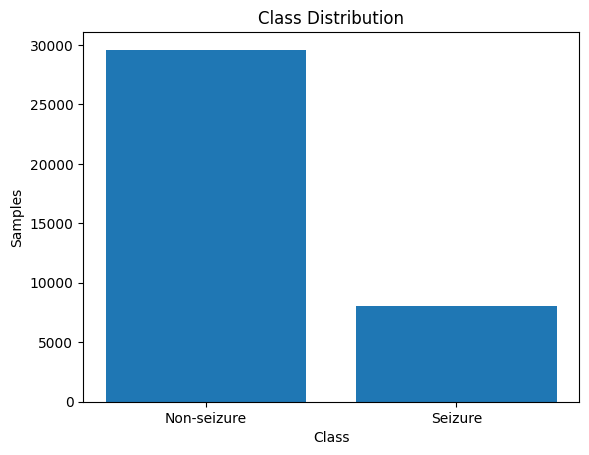

In [12]:
plt.bar(['Non-seizure', 'Seizure'], counts)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.show()

In [13]:
X_normalized = (X - X.mean(axis=2, keepdims=True)) / X.std(axis=2, keepdims=True)
print("X normalized shape:", X_normalized.shape)

C:\Users\Sukanya\AppData\Local\Temp\ipykernel_15208\67040507.py:1: RuntimeWarning: invalid value encountered in divide
  X_normalized = (X - X.mean(axis=2, keepdims=True)) / X.std(axis=2, keepdims=True)


X normalized shape: (37666, 23, 256)


In [14]:
X_lstm = np.transpose(X_normalized, (0, 2, 1))
print("X for LSTM shape:", X_lstm.shape)

X for LSTM shape: (37666, 256, 23)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (30132, 23, 256)
Validation shape: (7534, 23, 256)


In [16]:
X = np.transpose(X_normalized,(0, 2, 1))
print("X reshaped for BILSTM+CNN:",X.shape)

X reshaped for BILSTM+CNN: (37666, 256, 23)


In [20]:
pip install tensorflow

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/375.9 MB ? eta -:--:--
   ---------------------------------------- 1.8/375.9 MB 9.1 MB/s eta 0:00:41
   ---------------------------------------- 3.7/375.9 MB 9.9 MB/s eta 0:00:38
    --------------------------------------- 5.5/375.9 MB 9.1 MB/s eta 0:00:41
    --------------------------------------- 7.6/375.9 MB 9.4 MB/s eta 0:00:40
   - -------------------------------------- 9.4/375.9 MB 9.5 MB/s eta 0:00:39
   - -------------------------------------- 11.8/375.9 MB 9.6 MB/s eta 0:00:38
   - -------------------------------------- 14.2/375.9 MB 9.9 MB/s eta 0:00:37
   - -------------------------------------- 16.3/375.9 MB 9.9 MB/s eta 0:00:37
   - -------------------------------------- 18.1/375.9 MB 9.8 MB/s eta 0:00:37
   -- ------------------------------------- 19.9/375.9 MB 9.5 MB/s eta 0:00:38
   -- ------------------------------------- 21.0/375.9 MB 9.3 MB/s eta 0:00:39
  

  You can safely remove it manually.
  You can safely remove it manually.


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [21]:
import tensorflow as tf
from tensorflow.keras.layers import Layer


In [29]:
class Attention(Layer):
    def __init__(self):
        super(Attention, self).__init__()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer='normal',
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        alpha = tf.keras.backend.softmax(e, axis=1)
        context = inputs * alpha
        context = tf.keras.backend.sum(context, axis=1)
        return context

In [31]:
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
cnn = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(input_layer)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(cnn)
cnn = MaxPooling1D(pool_size=2)(cnn)
lstm = Bidirectional(LSTM(64, return_sequences=True))(cnn)
lstm = Bidirectional(LSTM(32, return_sequences=True))(lstm)
attn = Attention()(lstm)
drop = Dropout(0.4)(attn)
dense = Dense(64, activation='relu', 
               kernel_regularizer=regularizers.l2(0.01))(drop)
output = Dense(1, activation='sigmoid')(dense)
model = Model(inputs=input_layer, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 256, 23)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 256, 128)            │          14,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 128, 64)             │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 64, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 64, 128)             │          66,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 64, 64)              │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_2 (Attention)              │ (None, 64)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,105 (590.25 KB)

 Trainable params: 151,105 (590.25 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 60s 56ms/step - accuracy: 0.7863 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 2/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.7852 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 3/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.7832 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 4/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.7825 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 5/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.7905 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 6/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.7884 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 7/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.7873 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 8/50
942/942 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.7864 - loss: nan - val_accuracy: 0.7856 - val_loss: nan
Epoch 9/

KeyboardInterrupt: 

In [26]:
loss, acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {acc:.4f}")

236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7860 - loss: 0.5192
Validation Accuracy: 0.7856


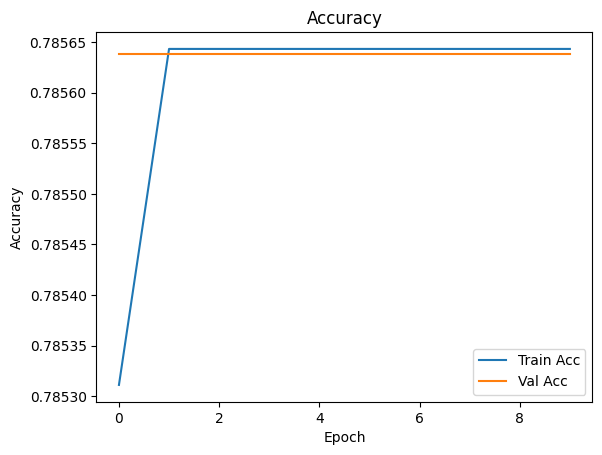

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


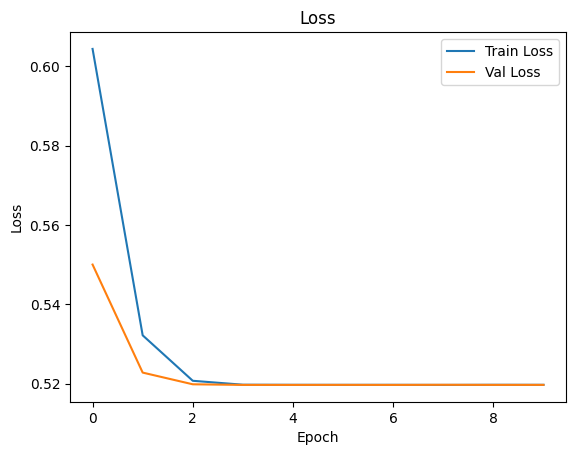

In [28]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
